# Homework 3
## Star Schema and Interactive Dashboard for Financial Transactions

**Datasets:** `symbols.csv`, `account-statement-1-1-2024-12-31-2024.csv`, `country.csv`

### Part 1 - Data Warehouse Modeling: Star Schema

### 1.1 Business Process and Fact Grain Definition

**Business Process:**
The business process under analysis is the management and tracking of financial transactions. Specifically, it monitors the execution of buy and sell orders for listed stocks across different market sectors, industries, and geographic regions.

**Fact Grain:**
One single row in the `Fact_Transactions` table represents **one transaction from the account statement file**. The grain is therefore the single business event (an *event/transaction fact*, as classified in the course slides on logical modeling).

## 1.2 Identify Fact and Dimensions

Based on the provided datasets, each source attribute is assigned either to the fact table or to exactly one dimension table, avoiding any unnecessary duplication of attributes across dimensions (e.g., `country` lives only in `Dim_Geography` and is **not** repeated inside `Dim_Symbol`, even though the source file `symbols.csv` carries it next to the company data).

### 1. Dimension Tables

* **`Dim_Time`** (from the `Date` field of the account statement)
  * `Date` *(natural key)* plus the calendar attributes derived from it (day, month, quarter, year, day of week)

* **`Dim_TransactionType`** (from the `TransactionType` field of the account statement)
  * `TransactionType` *(natural key)*

* **`Dim_Symbol`** (from `symbols.csv`)
  * `Symbol` *(natural key)*
  * `company_name`
  * `industry`
  * `sector`

* **`Dim_Geography`** (from `country.csv`, restricted to the countries that actually appear in `symbols.csv`)
  * `country` *(natural key)*
  * `sub-region`
  * `region`

  I drop `intermediate-region` (and the various ISO code columns) because they are not needed by any of the analyses and `intermediate-region` is empty for most rows.

### 2. Fact Table

* **`Fact_Transactions`**
  * `IDTransaction` *(descriptive attribute kept for traceability towards the source file)*
  * `Date` *(reference to Dim_Time)*
  * `TransactionType` *(reference to Dim_TransactionType)*
  * `Symbol` *(reference to Dim_Symbol)*
  * `country` *(reference to Dim_Geography, derived from the country of the traded company)*
  * `Unit` *(quantitative **measure**: number of units traded, additive via SUM)*


## 1.3 Define Dimension Hierarchies

Based on the dimensions identified in the previous step, the logical hierarchies are defined as follows:

### 1. Time Hierarchy (Dim_Time)
This structure allows time-series analysis and temporal aggregation (e.g., quarterly or monthly reporting).
* **Hierarchy:** Day $\rightarrow$ Month $\rightarrow$ Quarter $\rightarrow$ Year
* The *day of week* attribute is a **descriptive (cross) attribute** of the day level: it does not define an aggregation path on its own, but it supports analyses such as "units sold on Mondays".

### 2. Geography Hierarchy (Dim_Geography)
This hierarchy allows the analyst to explore financial transactions across different geopolitical levels, moving from specific countries up to large geographic areas.
* **Hierarchy:** Country $\rightarrow$ Sub-region $\rightarrow$ Region

### 3. Market/Industry Hierarchy (Dim_Symbol)
This hierarchy enables the aggregation of transaction metrics from individual tickers up to broad economic sectors.
* **Hierarchy:** Symbol $\rightarrow$ Industry $\rightarrow$ Sector
* `company_name` is a descriptive attribute at the Symbol level (a symbol and its company name are at the same level of detail).

### 4. Transaction Type Hierarchy (Dim_TransactionType)
* **Hierarchy:** none — it is a *degenerate* single-level dimension (BUY / SELL / DIVIDENT).

## 1.4 Design the Star Schema

Following the basic translation rule seen in the course slides (*"create a fact table containing all the measures and descriptive attributes directly connected with the fact and, for each hierarchy, create a dimension table containing all of its attributes"*), the final **ROLAP star schema** is:

* **Fact_Transactions** ( <u>TimeId (FK)</u>, <u>SymbolId (FK)</u>, <u>GeoId (FK)</u>, <u>TypeId (FK)</u>, IDTransaction, **Unit** )
* **Dim_Time** ( <u>TimeId (PK)</u>, Date, Day, DayOfWeek, Month, MonthName, Quarter, Year )
* **Dim_Symbol** ( <u>SymbolId (PK)</u>, Symbol, Company, Industry, Sector )
* **Dim_Geography** ( <u>GeoId (PK)</u>, Country, SubRegion, Region )
* **Dim_TransactionType** ( <u>TypeId (PK)</u>, TransactionType )

**Surrogate keys.** Every dimension receives an integer **surrogate key** (`TimeId`, `SymbolId`, `GeoId`, `TypeId`) generated during the ETL phase, instead of using the natural keys of the sources. This is the standard practice recommended in the logical design slides: surrogate keys are compact, stable over time and independent from the (possibly dirty) source values. This choice turned out to be particularly wise here, because during data cleaning (section 2.1) we discovered that `IDTransaction` is **not unique** in the source file, so it cannot be trusted as a key.

**Foreign keys.** Each fact row references exactly one member of each dimension: `TimeId` is derived from the transaction date, `SymbolId` from the traded ticker, `TypeId` from the transaction type and `GeoId` from the country of the company that issued the traded stock (the bridge `symbol` $\rightarrow$ `country` provided by `symbols.csv` is used only at ETL time and is not duplicated in `Dim_Symbol`).

**Measures and descriptive attributes.**
* `Unit` is the only explicit **measure**: it is *additive* (it can be summed along every dimension).
* The **number of transactions** is an implicit measure obtained with COUNT(*) over the fact rows.
* `IDTransaction` is kept as a **descriptive attribute** (a *degenerate* piece of information of the fact): it carries no analytical value but preserves the lineage towards the source file.

The cell below draws the diagram of the star schema (deliverable n. 3) and saves it as `star_schema.png`.

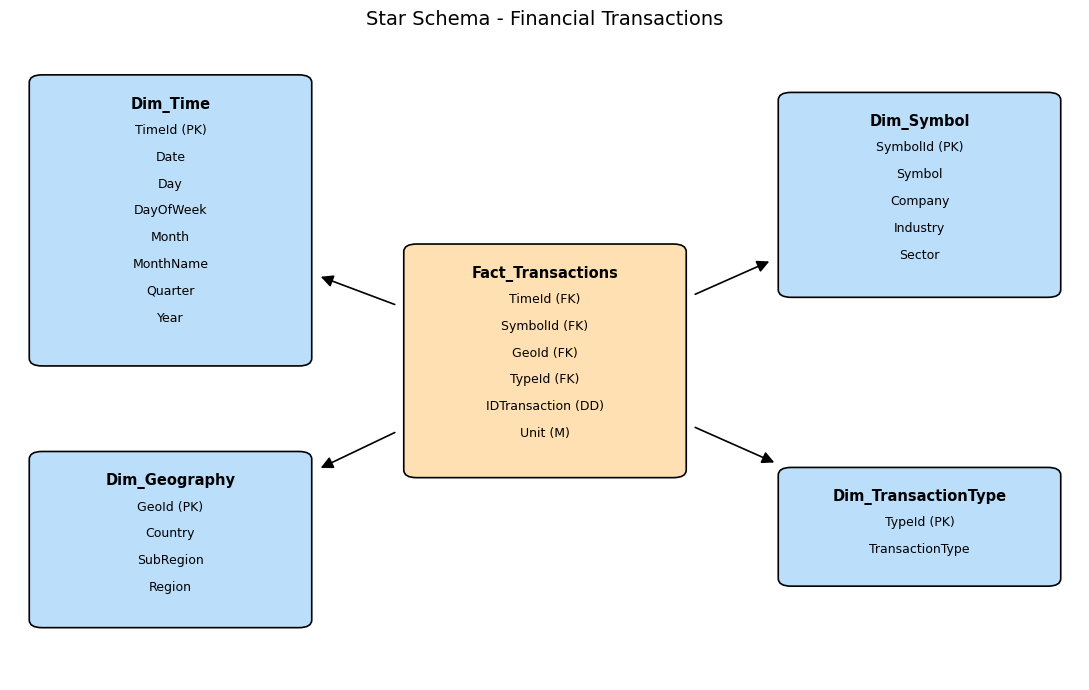

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


#Star Schema


# We draw the star schema with matplotlib: the fact table sits in the
# middle and the four dimension tables sit around it, each connected to
# the fact table by an arrow (the foreign-key relationship).

# (x, y) centre of each table box, its title and the list of attributes.
# 'PK' marks the surrogate primary key, 'FK' the foreign keys,
# 'M' the measure and 'DD' the degenerate/descriptive attribute.
tables = {
    'Fact_Transactions': {
        'xy': (0.50, 0.50), 'color': '#FFE0B2',
        'rows': ['TimeId (FK)', 'SymbolId (FK)', 'GeoId (FK)', 'TypeId (FK)',
                 'IDTransaction (DD)', 'Unit (M)']},
    'Dim_Time': {
        'xy': (0.15, 0.72), 'color': '#BBDEFB',
        'rows': ['TimeId (PK)', 'Date', 'Day', 'DayOfWeek', 'Month',
                 'MonthName', 'Quarter', 'Year']},
    'Dim_Symbol': {
        'xy': (0.85, 0.76), 'color': '#BBDEFB',
        'rows': ['SymbolId (PK)', 'Symbol', 'Company', 'Industry', 'Sector']},
    'Dim_Geography': {
        'xy': (0.15, 0.22), 'color': '#BBDEFB',
        'rows': ['GeoId (PK)', 'Country', 'SubRegion', 'Region']},
    'Dim_TransactionType': {
        'xy': (0.85, 0.24), 'color': '#BBDEFB',
        'rows': ['TypeId (PK)', 'TransactionType']},
}

fig, ax = plt.subplots(figsize=(11, 7)) #plt.subplots() returns a tuple: figure, area. In In figsize=(), I enter the size in inches
#fig is the sheet, ax  is the area where we draw. 
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off') #I’ve set the x-axis limits to 0 to 1, the same for the y-axis and I’m removing the axes from the drawing


        
sizes = {}                                       # empty dict: will store each box size (w,h), needed later for the arrows
for name, spec in tables.items():                # loop over the 5 tables: name = table name, spec = its dict {xy, color, rows}
    cx, cy = spec['xy']                          # unpack the box centre: cx = centre-x, cy = centre-y
    n_rows = len(spec['rows'])                    # count the table's attributes (used to size the box height)
    w, h = 0.24, 0.045 * (n_rows + 1.6)          # w = fixed width; h = height that grows with the number of rows
    sizes[name] = (w, h)                          # remember this box size under the table name
    # rounded rectangle for the table
    box = FancyBboxPatch((cx - w / 2, cy - h / 2), w, h,   # build the rectangle: from the centre get the bottom-left corner (centre - half size)
                         boxstyle='round,pad=0.012',        # rounded corners with a small inner padding
                         facecolor=spec['color'], edgecolor='black', linewidth=1.2)  # fill colour, black border, border thickness
    ax.add_patch(box)                             # add the built rectangle to the drawing area
    # table name (bold) on the first line, then one line per attribute
    ax.text(cx, cy + h / 2 - 0.035, name, ha='center', va='center',   # write the table NAME near the top (cy+h/2 = top edge, -0.035 nudges down)
            fontsize=10.5, fontweight='bold')     # larger, bold font: it is the heading
    for i, attr in enumerate(spec['rows']):       # loop over attributes: i = running index (0,1,2...), attr = attribute text
        ax.text(cx, cy + h / 2 - 0.075 - i * 0.042, attr,   # write the attribute; -0.075 places it below the title, -i*0.042 drops one row each time
                ha='center', va='center', fontsize=9)        # centred on the point (horiz. and vert.), smaller font
        



def edge_point(c_from, c_to, box_size, margin=0.018):   # function: find the point on the EDGE of the box centred in c_to, coming from c_from
    """Point where the segment c_from -> c_to crosses the border of the box
    centred in c_to (so arrows start/end exactly on the box edges)."""
    (x0, y0), (x1, y1) = c_from, c_to             # unpack coordinates: (x0,y0) = start, (x1,y1) = end
    vx, vy = x1 - x0, y1 - y0                      # direction vector start->end: displacement in x (vx) and y (vy)
    w2, h2 = box_size[0] / 2 + margin, box_size[1] / 2 + margin   # half-width and half-height of the target box (+ margin gap)
    # fraction of the segment at which each side of the box is reached
    tx = (abs(vx) - w2) / abs(vx) if vx != 0 else 1   # t (0=start,1=centre) at which the VERTICAL sides are hit; if vx=0 -> 1 (neutral)
    ty = (abs(vy) - h2) / abs(vy) if vy != 0 else 1   # t at which the HORIZONTAL sides are hit; if vy=0 -> 1 (neutral)
    t = max(tx, ty)                              # enter the rectangle at the larger of the two: BOTH limits must be met
    return (x0 + t * vx, y0 + t * vy)             # apply that t to the segment: return the exact point on the edge

    


# arrows: fact table -> each dimension (FK relationships)
f_center = tables['Fact_Transactions']['xy']      # centre of the fact (0.50, 0.50): fixed point where all arrows start
for dim in ['Dim_Time', 'Dim_Symbol', 'Dim_Geography', 'Dim_TransactionType']:   # loop over the 4 dimensions
    d_center = tables[dim]['xy']                  # centre of the current dimension
    start = edge_point(d_center, f_center, sizes['Fact_Transactions'])  # start point: on the edge of the FACT box
    end = edge_point(f_center, d_center, sizes[dim])                    # end point: on the edge of the DIMENSION box
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>',          # build the edge-to-edge arrow, triangular head '-|>'
                                 mutation_scale=18, color='black', linewidth=1.2))  # head size, colour and thickness; add it to the canvas



plt.title('Star Schema - Financial Transactions', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('star_schema.png', dpi=150, bbox_inches='tight')   # deliverable n.3
plt.show()


## Part 2 - Data Transformation and Analysis

### 2.1 Load and Clean the Data

In this section we implement the **ETL process** (Extract, Transform and Load) that feeds the star schema, following the three phases described in the course slides:

1. **Extraction:** loading the three raw CSV files;
2. **Transformation** (cleansing + conforming): fixing structural problems, checking missing values, removing unused attributes, parsing dates, reconciling country names and enforcing **referential integrity** between the transactions and the dimensions;
3. **Loading:** building the dimension dataframes (with surrogate keys) and the fact dataframe.

As stated in the assignment, each dataframe keeps **only** the information included in the dimensional model designed in Part 1.

In [2]:
import pandas as pd
import numpy as np


# STEP 1: EXTRACTION : I Load the raw datasets

# Inspecting the raw files first (a recommended practice in the ETL slides:
# 'inspect and normalize the sources before integrating them') shows that
# the three CSVs do NOT share the same separator:
#   - symbols.csv and the account statement use ';'
#   - country.csv uses the standard ','

raw_symbols = pd.read_csv('symbols.csv', sep=';') 
raw_tx = pd.read_csv('account-statement-1-1-2024-12-31-2024.csv', sep=';')
raw_country = pd.read_csv('country.csv')

print(f'symbols.csv           -> {raw_symbols.shape[0]} rows, {raw_symbols.shape[1]} columns: {list(raw_symbols.columns)}')
print(f'account statement     -> {raw_tx.shape[0]} rows, {raw_tx.shape[1]} columns: {list(raw_tx.columns)}')
print(f'country.csv           -> {raw_country.shape[0]} rows, {raw_country.shape[1]} columns')


# NOTE: for symbols.csv and the account statement we also print the column
# names, because that is where the fact and the key attributes come from and
# because printing them makes the structural anomaly visible (the trailing ';'
# in the account statement creates the empty 'Unnamed: 5' column). For
# country.csv we only print the row/column counts: it is a pure lookup file of
# which we will keep just 3 of its 11 columns (name, sub-region, region), so
# listing all the ISO-code columns here would only add noise. We just need to
# confirm it was read correctly with the comma separator.

symbols.csv           -> 3194 rows, 5 columns: ['symbol', 'company_name', 'sector', 'industry', 'country']
account statement     -> 2745 rows, 6 columns: ['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit', 'Unnamed: 5']
country.csv           -> 249 rows, 11 columns


In [3]:

# STEP 2: Trasformation - Part 1: CLEANSING - Structural fixes and data quality checks


# The account statement has a structural problem: every line seems to end with
# a trailing ';', so pandas creates a completely empty extra column
# ('Unnamed: 5'). Let's verify that this is really the cause before removing it.

# --- Proof at the character level: we open the raw file as plain text and
# print its first lines exactly as they are stored on disk. repr() is used
# so that we SEE the real characters (the trailing ';' becomes visible at the
# end of each line, instead of being hidden as an invisible line break).
with open('account-statement-1-1-2024-12-31-2024.csv', encoding='utf-8') as f:  # open the file in read mode
    for i in range(3):                  # look only at the first 3 lines (header + 2 rows)
        print(repr(f.readline()))       # readline() reads one line; repr() shows the exact raw characters

# The checks confirm the cause is a trailing ';' at the end of every line:
#   - the header declares 5 fields (4 ';'), yet pandas built 6 columns, which
#     means every row actually contains 5 ';' - one separator too many;
#   - that extra column is the LAST one, it is completely empty and it has no
#     name in the header, so pandas auto-named it 'Unnamed: 5' - the typical
#     signature of a separator placed AFTER the last real value;
#   - the raw lines printed above literally end with ';', confirming it.
# The column therefore carries no information and we remove it.
tx = raw_tx.drop(columns=['Unnamed: 5'])



# MISSING VALUES CHECK on the transaction log.
# Count of missing values per column: if the count is the same for every column, 
# this is a strong indication that the gaps consist of entire empty rows, rather than scattered missing cells.
print('\n Missing values per column (account statement):')
print(tx.isna().sum().to_string())


# The missing values are not scattered: they come from rows that are
# COMPLETELY empty (an export artifact of the source system), so we can
# safely drop them without losing any real transaction.
fully_empty = tx.isna().all(axis=1).sum()   # count the fully-empty rows (axis=1 = row-wise; .all() = every cell missing)
tx = tx.dropna(how='all')                    # drop a row only if ALL its cells are missing (how='all')
print(f'\nRemoved {fully_empty} completely empty rows -> {len(tx)} real transactions remain.')  # report removed vs. remaining

# TYPE CONVERSIONS.
# Dates arrive as strings in day/month/year format: we parse them with an
# explicit format (safer than letting pandas guess month/day order).
tx['Date'] = pd.to_datetime(tx['Date'], format='%d/%m/%Y %H:%M:%S')
#I use pd.to_datetime(), because in this way i can choose if we can write the day frist and then month or viceversa

tx['Unit'] = tx['Unit'].astype(int)
tx['IDTransaction'] = tx['IDTransaction'].astype('int64')
# Units and transaction ids became floats because of the empty rows (a column
# with even one NaN is promoted to float by pandas): now that the NaNs are gone
# I convert them back to integers.
# int vs int64: both yield integer columns and the effect is essentially the
# same (on 64-bit systems 'int' already maps to int64). I use int64 explicitly
# for IDTransaction to make clear it must hold very large id numbers (e.g.
# 2769834124); for Unit, which holds small quantities, the generic int is fine.


# Sanity checks on the parsed values: the statement must cover 2024 (to verify if the name of the data set is reliable) only
# and the measure must be strictly positive.
print(f"\nDate range: {tx['Date'].min()} -> {tx['Date'].max()} (all in 2024: {(tx['Date'].dt.year == 2024).all()})")
print(f"Non-positive units: {(tx['Unit'] <= 0).sum()}")

# DUPLICATE CHECK on the natural key of the source.
# IDTransaction *should* identify a transaction, but it does not:
dup_ids = tx['IDTransaction'].duplicated().sum()
full_dup = tx.duplicated().sum()
print(f'\nDuplicated IDTransaction values: {dup_ids} (out of {len(tx)} rows)')
print(f'Fully duplicated rows: {full_dup}')
# The same id is reused by transactions with different dates, symbols and
# units, while no row is duplicated in full. Conclusion: the rows are
# genuine distinct transactions and IDTransaction is just an unreliable
# code -> we keep it only as a descriptive attribute, consistently with
# the grain ('one row = one transaction from the account statement file').

# DOMAIN CHECK on the transaction type.
print('\nTransaction types found:')
print(tx['TransactionType'].value_counts().to_string())
# Besides BUY and SELL the file contains DIVIDENT (sic) rows: dividend
# payments. They are legitimate transactions of the account statement, so
# they STAY in the fact table (the grain demands it); the analytical
# queries of section 2.2 will simply filter BUY/SELL when needed.

# Missing values on the other two sources.
print(f'\nMissing values in symbols.csv: {raw_symbols.isna().sum().sum()}')
print(f'Duplicated tickers in symbols.csv: {raw_symbols["symbol"].duplicated().sum()}')



'\ufeffIDTransaction;Date;TransactionType;Symbol;Unit;\n'
'2769834124;11/01/2024 10:44:03;BUY;BAP;1605;\n'
'2767324642;24/01/2024 08:07:24;SELL;BAP;1605;\n'

 Missing values per column (account statement):
IDTransaction      464
Date               464
TransactionType    464
Symbol             464
Unit               464

Removed 464 completely empty rows -> 2281 real transactions remain.

Date range: 2024-01-02 14:33:01 -> 2024-12-30 15:00:09 (all in 2024: True)
Non-positive units: 0

Duplicated IDTransaction values: 1145 (out of 2281 rows)
Fully duplicated rows: 0

Transaction types found:
TransactionType
SELL        1089
BUY         1082
DIVIDENT     110

Missing values in symbols.csv: 0
Duplicated tickers in symbols.csv: 0


In [4]:

# STEP 2 TRANSFORMATION - Part 2 Conforming : Referential integrity between the sources


# Every transaction symbol must exist in the symbols dataset.
orphan_mask = ~tx['Symbol'].isin(raw_symbols['symbol'])
orphan_symbols = sorted(tx.loc[orphan_mask, 'Symbol'].unique())
print(f'Transactions whose symbol is NOT in symbols.csv: {orphan_mask.sum()} rows, {len(orphan_symbols)} distinct tickers')
print(f'Orphan tickers: {orphan_symbols}')

# Without a match in symbols.csv we cannot resolve the Dim_Symbol (and
# consequently the Dim_Geography) foreign keys, so these rows cannot be
# loaded into the star schema. We exclude them and document the loss.
before = len(tx)
tx = tx[~orphan_mask].copy()
print(f'-> {before - len(tx)} rows excluded; {len(tx)} transactions will be loaded into the fact table.')

# Every company country must be mappable to country.csv.
unmapped = sorted(set(raw_symbols['country']) - set(raw_country['name']))
print(f'\nCompany countries with no match in country.csv: {unmapped}')


# How to find the correct target names: the two unmapped countries are
# 'Turkey' and 'Taiwan' (as spelled in symbols.csv). To discover how country.csv
# spells those same countries, we search its 'name' column for a fragment of the
# word (we don't know the full official spelling yet, so we match a substring).
for fragment in ['rk', 'Tai']:                                   # 'rk' -> Turkey, 'Tai' -> Taiwan
    matches = raw_country.loc[                                   # keep the names that contain the fragment
        raw_country['name'].str.contains(fragment, case=False, na=False), 'name'
    ].to_list()
    print(f"country.csv names containing '{fragment}': {matches}")
# -> the official ISO 3166 spellings turn out to be 'Türkiye' and
#    'Taiwan, Province of China', which is exactly the mapping we apply below.


# symbols.csv almost always uses the official ISO 3166 names; only two
# countries use a colloquial spelling. We reconcile them explicitly
# (a classic 'naming conflict' resolved in the integration phase):
COUNTRY_NAME_FIXES = {
    'Turkey': 'Türkiye',
    'Taiwan': 'Taiwan, Province of China',
}



symbols = raw_symbols.copy()
symbols['country'] = symbols['country'].replace(COUNTRY_NAME_FIXES)

still_unmapped = sorted(set(symbols['country']) - set(raw_country['name']))
print(f'After the name fixes, unmapped countries: {still_unmapped}')



Transactions whose symbol is NOT in symbols.csv: 212 rows, 18 distinct tickers
Orphan tickers: ['AGO.l', 'ARCH', 'AZM', 'CCAP', 'CSIQ', 'FNC', 'HTGC', 'IBE', 'MFG', 'MONC', 'OBDC', 'RCMT', 'RIGZU', 'SAP', 'TKC', 'UCG', 'VWS', 'WF']
-> 212 rows excluded; 2069 transactions will be loaded into the fact table.

Company countries with no match in country.csv: ['Taiwan', 'Turkey']
country.csv names containing 'rk': ['Burkina Faso', 'Denmark', 'Türkiye', 'Turkmenistan', 'Turks and Caicos Islands']
country.csv names containing 'Tai': ['Taiwan, Province of China', 'United Kingdom of Great Britain and Northern Ireland']
After the name fixes, unmapped countries: []


In [5]:

# STEP 3: LOADING - Part 1: Building the dimension tables (with surrogate keys)

# Each dimension keeps ONLY the attributes of the dimensional model and
# receives a compact integer surrogate key starting from 1.

# Dim_Time: one row per calendar day appearing in the statement.
# The surrogate key uses the readable YYYYMMDD convention (e.g. 20240116).
dim_time = pd.DataFrame({'Date': sorted(tx['Date'].dt.normalize().unique())}) #set every time in 00:00
dim_time['TimeId'] = dim_time['Date'].dt.strftime('%Y%m%d').astype(int)
dim_time['Day'] = dim_time['Date'].dt.day                # day of the month (1-31)
dim_time['DayOfWeek'] = dim_time['Date'].dt.day_name()   # Monday, Tuesday, ...
dim_time['Month'] = dim_time['Date'].dt.month            # 1-12
dim_time['MonthName'] = dim_time['Date'].dt.month_name() # January, ...
dim_time['Quarter'] = dim_time['Date'].dt.quarter        # 1-4
dim_time['Year'] = dim_time['Date'].dt.year
dim_time = dim_time[['TimeId', 'Date', 'Day', 'DayOfWeek', 'Month', 'MonthName', 'Quarter', 'Year']]

#Dim_Symbol: descriptive attributes of the traded companies.
# NOTE: 'country' is intentionally NOT kept here (it belongs to
# Dim_Geography); it will be used only as a bridge to assign the GeoId
# foreign key in Step 5.
dim_symbol = symbols[['symbol', 'company_name', 'industry', 'sector']].copy()
dim_symbol.columns = ['Symbol', 'Company', 'Industry', 'Sector']
dim_symbol.insert(0, 'SymbolId', range(1, len(dim_symbol) + 1))

# Dim_Geography: only the countries that actually host listed companies,
# enriched with sub-region and region from country.csv. All the other
# columns of country.csv (ISO codes, intermediate region, ...) are unused
# attributes and are removed, as required by the assignment.
dim_geography = (raw_country[['name', 'sub-region', 'region']]
                 .rename(columns={'name': 'Country', 'sub-region': 'SubRegion', 'region': 'Region'}))
dim_geography = dim_geography[dim_geography['Country'].isin(symbols['country'])].reset_index(drop=True)

# Before fixing anything, we CHECK which countries (among those kept in the
# dimension) have a missing Region or SubRegion in country.csv. This shows the
# fix below is targeted, not arbitrary: only Taiwan needs it.
missing_geo = dim_geography[dim_geography['Region'].isna() | dim_geography['SubRegion'].isna()]
print('Countries with a missing Region/SubRegion in country.csv:')
print(missing_geo.to_string(index=False))



# Data quality fix: in the ISO file 'Taiwan, Province of China' has no
# region/sub-region. We complete the hierarchy manually (it belongs to
# Asia / Eastern Asia) so that roll-ups to Region never lose rows.
taiwan = dim_geography['Country'] == 'Taiwan, Province of China'
dim_geography.loc[taiwan, ['Region', 'SubRegion']] = ['Asia', 'Eastern Asia']
dim_geography.insert(0, 'GeoId', range(1, len(dim_geography) + 1))

#Dim_TransactionType: the three transaction types found in Step 2.
dim_type = pd.DataFrame({'TransactionType': sorted(tx['TransactionType'].unique())})
dim_type.insert(0, 'TypeId', range(1, len(dim_type) + 1))

print(f'\n Dim_Time            : {dim_time.shape[0]} rows  (distinct trading days)')
print(f'Dim_Symbol          : {dim_symbol.shape[0]} rows  (listed companies)')
print(f'Dim_Geography       : {dim_geography.shape[0]} rows  (countries with listed companies)')
print(f'Dim_TransactionType : {dim_type.shape[0]} rows  ({list(dim_type["TransactionType"])})')

print('\nPreview of Dim_Time:')
display(dim_time.head(3))
print('Preview of Dim_Geography:')
display(dim_geography.head(3))
print('Display of Dim_Type:')
display(dim_type)



Countries with a missing Region/SubRegion in country.csv:
                  Country SubRegion Region
Taiwan, Province of China       NaN    NaN

 Dim_Time            : 228 rows  (distinct trading days)
Dim_Symbol          : 3194 rows  (listed companies)
Dim_Geography       : 42 rows  (countries with listed companies)
Dim_TransactionType : 3 rows  (['BUY', 'DIVIDENT', 'SELL'])

Preview of Dim_Time:


,TimeId,Date,Day,DayOfWeek,Month,MonthName,Quarter,Year
0,20240102,2024-01-02,2,Tuesday,1,January,1,2024
1,20240103,2024-01-03,3,Wednesday,1,January,1,2024
2,20240104,2024-01-04,4,Thursday,1,January,1,2024


Preview of Dim_Geography:


,GeoId,Country,SubRegion,Region
0,1,Australia,Australia and New Zealand,Oceania
1,2,Bahamas,Latin America and the Caribbean,Americas
2,3,Bermuda,Northern America,Americas


Display of Dim_Type:


,TypeId,TransactionType
0,1,BUY
1,2,DIVIDENT
2,3,SELL


In [6]:

# STEP 3: LOADING - Part 2: Building the fact table

# Each transaction is mapped to the surrogate keys of the four dimensions
# ('looking up keys', as the ETL slides call this step).

fact = tx.copy()

# TimeId: derived from the transaction date with the same YYYYMMDD rule used in Dim_Time.
fact['TimeId'] = fact['Date'].dt.strftime('%Y%m%d').astype(int)

# SymbolId: looked up from Dim_Symbol via the ticker; we also carry the
# company country (from the conformed symbols dataframe) as a bridge.
bridge = symbols[['symbol', 'country']].merge(
    dim_symbol[['SymbolId', 'Symbol']], left_on='symbol', right_on='Symbol')
fact = fact.merge(bridge[['symbol', 'country', 'SymbolId']],
                  left_on='Symbol', right_on='symbol', how='left')

# GeoId: looked up from Dim_Geography via the company country.
fact = fact.merge(dim_geography[['GeoId', 'Country']],
                  left_on='country', right_on='Country', how='left')

# TypeId: looked up from Dim_TransactionType.
fact = fact.merge(dim_type, on='TransactionType', how='left')

# Final projection: the fact table keeps ONLY the four foreign keys, the
# measure and the descriptive attribute, exactly as designed in 1.4.
fact_transactions = fact[['TimeId', 'SymbolId', 'GeoId', 'TypeId', 'IDTransaction', 'Unit']].copy()

# Integrity check: after the lookups no foreign key may be missing.
assert fact_transactions[['TimeId', 'SymbolId', 'GeoId', 'TypeId']].notna().all().all(), 'Unresolved foreign keys!'

print(f'Fact_Transactions: {fact_transactions.shape[0]} rows, {fact_transactions.shape[1]} columns')
print('\nPreview of the fact table:')
display(fact_transactions.head(5))



Fact_Transactions: 2069 rows, 6 columns

Preview of the fact table:


,TimeId,SymbolId,GeoId,TypeId,IDTransaction,Unit
0,20240111,284,32,1,2769834124,1605
1,20240124,284,32,3,2767324642,1605
2,20240110,284,32,3,2815473914,914
3,20240116,4,3,1,2622244212,646
4,20240116,258,26,3,2629871124,646


#### Data quality summary (issues found in 2.1)

| # | Issue | Decision |
|---|-------|----------|
| 1 | The account statement ends every line with `;` → empty column `Unnamed: 5` | Column removed |
| 2 | 464 completely empty rows in the account statement | Rows removed (no information lost) |
| 3 | `IDTransaction` is **not unique** (1145 duplicated values on distinct transactions, no fully duplicated rows) | Kept as a descriptive attribute; surrogate keys used instead |
| 4 | Unexpected transaction type `DIVIDENT` (110 rows) | Kept in the fact table (consistent with the grain); filtered out by the BUY/SELL analyses |
| 5 | 212 transactions reference 18 tickers missing from `symbols.csv` | Excluded: their `Dim_Symbol`/`Dim_Geography` foreign keys cannot be resolved |
| 6 | `Turkey` and `Taiwan` do not match the ISO names in `country.csv` | Reconciled to `Türkiye` and `Taiwan, Province of China` |
| 7 | `Taiwan, Province of China` has empty region/sub-region in `country.csv` | Completed manually with `Asia` / `Eastern Asia` |
| 8 | Different separators across the CSVs (`;` vs `,`) | Handled at extraction time |

### 2.2 Analytical Questions

I answer **six** of the proposed questions, chosen so that every dimension and every hierarchy level of the star schema is exercised at least once (the last one, Q14, goes a step further by **crossing two hierarchies at once**):

* **Q1** - Top 5 *sectors* by number of SELL transactions in the US during 2024 *(Symbol hierarchy roll-up + Geography filter + Type filter)*;
* **Q3** - Rank of all *quarters* of 2024 by total number of transactions *(Time hierarchy roll-up)*;
* **Q5** - Top 5 *regions* by total units bought in 2024 *(Geography hierarchy roll-up on the additive measure)*;
* **Q7** - Top 10 *symbols* by number of transactions in 2024 *(finest level of the Symbol dimension)*;
* **Q12** - Top 3 *sectors* by units sold on *Mondays* *(cross attribute DayOfWeek of Dim_Time)*;
* **Q14** - Top 10 *industry-region pairs* by number of transactions *(cross-dimensional: Symbol-hierarchy roll-up to Industry combined with Geography-hierarchy roll-up to Region)*.

As shown in the OLAP slides, a multidimensional view over a star schema is obtained by **joining the fact table with its dimension tables**: the next cell builds this view once, and every question is then a filter + group-by over it.

In [7]:

# 2.2 SETUP: the OLAP view and a reusable plot helper


# The 'star join': fact table joined with the four dimension tables on the
# surrogate keys. Every analytical query below is a selection/aggregation
# over this multidimensional view (exactly the SELECT...JOIN pattern of
# the OLAP-over-star-schema slides, expressed with pandas).
star = (fact_transactions
        .merge(dim_time, on='TimeId')
        .merge(dim_symbol, on='SymbolId')
        .merge(dim_geography, on='GeoId')
        .merge(dim_type, on='TypeId'))

print(f'OLAP view: {star.shape[0]} rows, {star.shape[1]} columns')

# Convenience subset reused by most questions: market transactions only.
buy_sell = star[star['TransactionType'].isin(['BUY', 'SELL'])]


def plot_ranking(series, title, value_label, color='#1f77b4'):
    """Draw a horizontal bar chart for a ranking (a sorted pandas Series)."""
    # barh draws from the bottom up, so we re-sort ascending to get the
    # largest bar on top.
    s = series.sort_values(ascending=True)

    # Only the HEIGHT is dynamic (0.55 in per bar): in a horizontal bar chart
    # the number of categories grows vertically, so more bars need more height
    # to stay readable. The WIDTH stays fixed at 9 in because matplotlib
    # auto-scales the x-axis to the values, so a larger measure (e.g. 37,026 vs
    # 158) does not need a wider canvas - the longest bar fills the same space
    # regardless. Long category labels / value labels are handled by
    # tight_layout(), not by the width.
    plt.figure(figsize=(9, 0.55 * len(s) + 1.5))
    ax = plt.gca()

    # light vertical grid behind the bars, for readability
    ax.set_axisbelow(True)
    ax.grid(axis='x', linestyle='--', alpha=0.7, color='gray')
    # hide the top/right borders for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # barh (not bar): the categories are long labels (sector / country names),
    # which read horizontally on the y-axis instead of being squeezed and
    # rotated under vertical bars.
    bars = plt.barh([str(i) for i in s.index], s.values, color=color)

    # print the exact value at the tip of each bar (visual length + precise number)
    for bar in bars:
        ax.annotate(f'{bar.get_width():,.0f}',                          # value: thousands sep, no decimals
                    (bar.get_width(), bar.get_y() + bar.get_height() / 2),  # anchor: bar tip, vertically centred
                    ha='left', va='center', fontsize=9, xytext=(4, 0),      # small gap so text doesn't touch the bar
                    textcoords='offset points')

    plt.title(title, fontsize=13, pad=12)
    plt.xlabel(value_label, fontsize=11)   # x = the measure; categories label themselves on the y-axis
    plt.tight_layout()                     # auto-fit margins so long labels / value tags are not clipped
    plt.show()


OLAP view: 2069 rows, 21 columns


#### Q1 - Top 5 sectors by number of SELL transactions in the US during 2024

Top 5 US sectors by number of SELL transactions in 2024:
Sector
Technology                158
Communication Services     58
Financial Services         55
Healthcare                 50
Consumer Cyclical          48


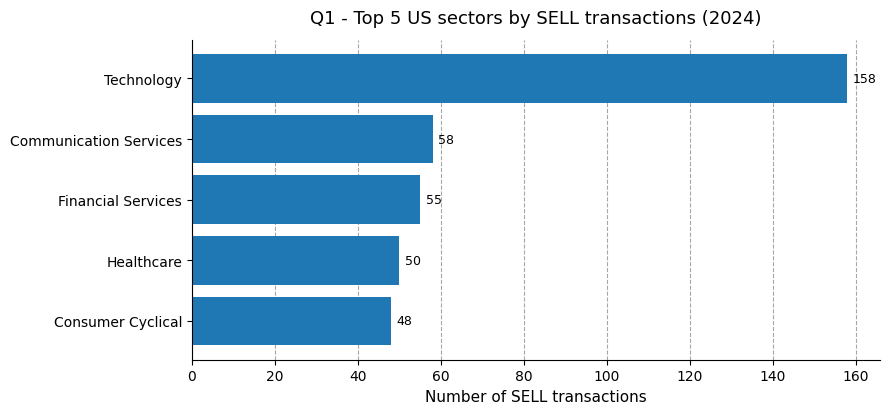

In [8]:

# Q1: TOP 5 SECTORS BY SELL TRANSACTIONS IN THE US (2024)

# Slice of the cube: TransactionType = SELL, Country = USA, Year = 2024;
# then roll-up along the Symbol hierarchy up to the Sector level,
# counting fact rows (the implicit 'number of transactions' measure).

q1 = (star[(star['TransactionType'] == 'SELL')
           & (star['Country'] == 'United States of America')
           & (star['Year'] == 2024)]
      .groupby('Sector')
      .size()                                  # COUNT(*) per sector
      .sort_values(ascending=False)
      .head(5))

print('Top 5 US sectors by number of SELL transactions in 2024:')
print(q1.to_string())
plot_ranking(q1, 'Q1 - Top 5 US sectors by SELL transactions (2024)', 'Number of SELL transactions')

**Interpretation (Q1):** selling activity on US stocks is strongly concentrated in **Technology** (158 SELL transactions), which alone almost triples the second sector. Communication Services, Financial Services, Healthcare and Consumer Cyclical follow in a tight band between ~48 and ~58 transactions: the portfolio turnover in the US is clearly tech-driven.

#### Q3 - Rank all quarters of 2024 by total number of transactions (BUY + SELL)

Quarters of 2024 ranked by number of transactions (BUY + SELL):
Q1 2024    968
Q2 2024    522
Q3 2024    242
Q4 2024    241


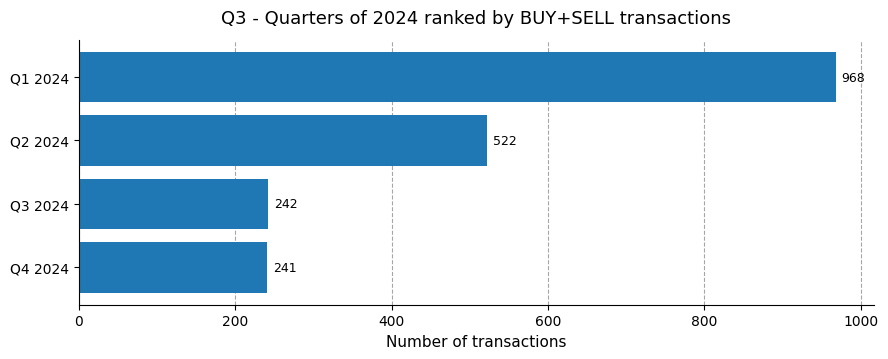

In [9]:

# Q3: QUARTERS OF 2024 RANKED BY TOTAL BUY+SELL TRANSACTIONS

# Roll-up along the Time hierarchy (Day -> Quarter), counting fact rows.
# DIVIDENT rows are excluded because the question asks for BUY + SELL.

q3 = (buy_sell[buy_sell['Year'] == 2024]
      .groupby('Quarter')
      .size()
      .sort_values(ascending=False))

# nicer labels for printing and plotting (Quarter 1 -> 'Q1 2024')
q3.index = [f'Q{q} 2024' for q in q3.index]

print('Quarters of 2024 ranked by number of transactions (BUY + SELL):')
print(q3.to_string())
plot_ranking(q3, 'Q3 - Quarters of 2024 ranked by BUY+SELL transactions', 'Number of transactions')

**Interpretation (Q3):** trading activity decreases monotonically through the year: **Q1 (968 transactions)** accounts for almost half of the yearly volume, Q2 roughly halves it (522), and the second semester is much quieter, with Q3 (242) and Q4 (241) practically tied. The account was therefore managed very actively at the beginning of 2024 and almost passively at the end.

#### Q5 - Top 5 regions by total units bought in 2024

Top regions by total units bought in 2024:
Region
Americas    37026
Europe      22528
Asia        11537

Note: the dimension contains 5 regions, but only 3 appear in the BUY transactions.


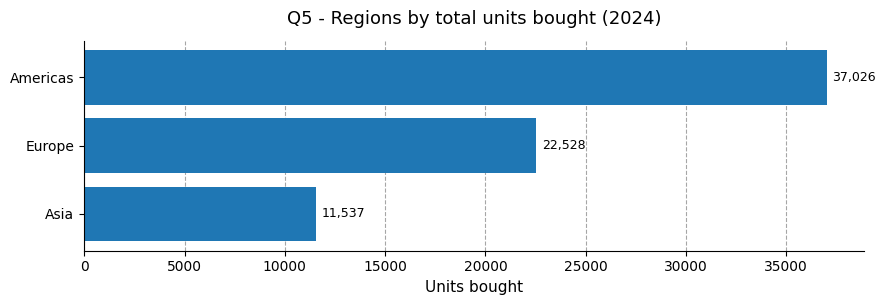

In [10]:

# Q5: TOP 5 REGIONS BY TOTAL UNITS BOUGHT (2024)

# Slice: TransactionType = BUY, Year = 2024; roll-up along the Geography
# hierarchy up to its top level (Region), this time aggregating the
# ADDITIVE measure Unit with SUM instead of counting rows.

q5 = (star[(star['TransactionType'] == 'BUY') & (star['Year'] == 2024)]
      .groupby('Region')['Unit']
      .sum()                                   # SUM(Unit) per region
      .sort_values(ascending=False)
      .head(5))

print('Top regions by total units bought in 2024:')
print(q5.to_string())
print(f'\nNote: the dimension contains {dim_geography["Region"].nunique()} regions, but only {len(q5)} appear in the BUY transactions.')
plot_ranking(q5, 'Q5 - Regions by total units bought (2024)', 'Units bought')

**Interpretation (Q5):** the question asks for a top 5, but the purchased stocks belong to companies from only **three** regions — a finding in itself. The **Americas dominate with 37,026 units bought**, followed by Europe (22,528) and Asia (11,537); Oceania and Africa never appear among the BUY transactions, even though African and Oceanian companies exist in `symbols.csv`.

#### Q7 - Top 10 symbols by number of transactions (BUY + SELL) in 2024

Top 10 symbols by number of transactions (BUY + SELL) in 2024:
Symbol
ARM     100
AMD      97
TSM      77
TIMB     76
GOOG     48
AMZN     47
MSFT     45
ARDX     43
BRFS     42
RDDT     40


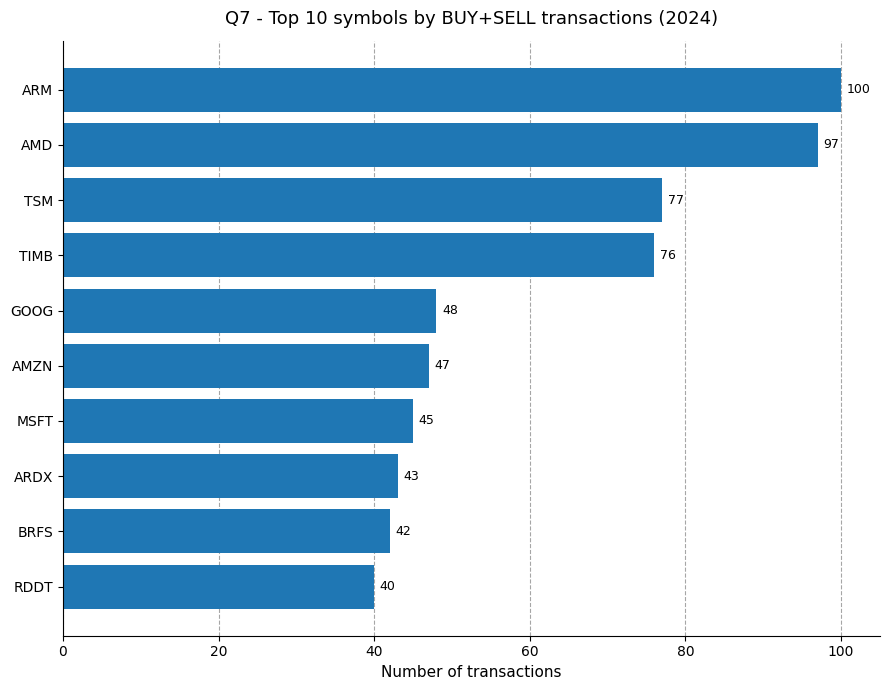

In [11]:

# Q7: TOP 10 SYMBOLS BY NUMBER OF TRANSACTIONS (BUY + SELL, 2024)

# Same counting measure as Q1/Q3, but at the FINEST level of the Symbol
# hierarchy (the individual ticker), keeping both BUY and SELL rows.

q7 = (buy_sell[buy_sell['Year'] == 2024]
      .groupby('Symbol')
      .size()
      .sort_values(ascending=False)
      .head(10))

print('Top 10 symbols by number of transactions (BUY + SELL) in 2024:')
print(q7.to_string())
plot_ranking(q7, 'Q7 - Top 10 symbols by BUY+SELL transactions (2024)', 'Number of transactions')

**Interpretation (Q7):** the most traded tickers confirm the tech orientation seen in Q1: the podium is **ARM (100)**, **AMD (97)** and **TSM (77)** — all semiconductor companies — followed by the Brazilian telecom TIMB (76). Big-tech names (GOOG, AMZN, MSFT) sit mid-table around 45-48 transactions, showing that the account concentrates its turnover on a handful of chip stocks.

#### Q12 - Top 3 sectors by total number of units sold on Mondays across 2024

Top 3 sectors by units sold on Mondays in 2024:
Sector
Technology           4361
Healthcare           2108
Consumer Cyclical    1218


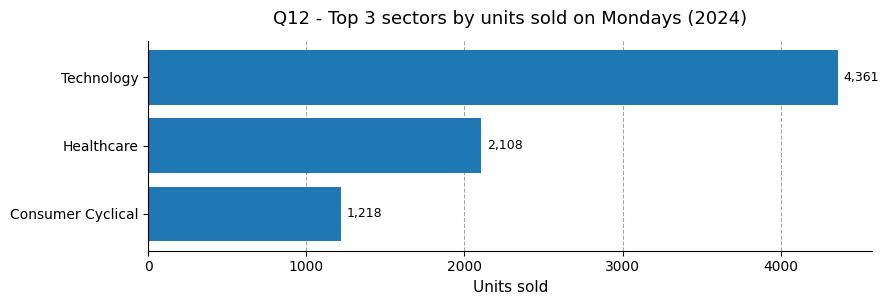

In [12]:

# Q12: TOP 3 SECTORS BY UNITS SOLD ON MONDAYS (2024)

# Slice: TransactionType = SELL and DayOfWeek = 'Monday' (the descriptive
# cross attribute of Dim_Time); roll-up to Sector summing the Unit measure.

q12 = (star[(star['TransactionType'] == 'SELL')
            & (star['DayOfWeek'] == 'Monday')
            & (star['Year'] == 2024)]
       .groupby('Sector')['Unit']
       .sum()
       .sort_values(ascending=False)
       .head(3))

print('Top 3 sectors by units sold on Mondays in 2024:')
print(q12.to_string())
plot_ranking(q12, 'Q12 - Top 3 sectors by units sold on Mondays (2024)', 'Units sold')

**Interpretation (Q12):** even restricting the analysis to Mondays only, **Technology leads with 4,361 units sold**, roughly twice Healthcare (2,108) and more than three times Consumer Cyclical (1,218). This is consistent with Q1 and Q7: whatever the angle (transaction counts, units, specific weekdays), the portfolio activity revolves around technology stocks.

This question also shows the value of having modeled `DayOfWeek` as a descriptive attribute of `Dim_Time`: the query is a simple slice on the dimension, with no date arithmetic in the analytical code.

#### Q14 - Top 10 industry-region pairs by number of transactions (BUY + SELL) in 2024

Top 10 industry-region pairs by BUY+SELL in 2024:
Semiconductors - Americas                    133
Software - Infrastructure - Americas         128
Internet Content & Information - Americas    112
Semiconductors - Europe                      100
Semiconductors - Asia                         91
Telecom Services - Americas                   81
Biotechnology - Europe                        66
Software - Application - Americas             60
Auto Manufacturers - Asia                     60
Biotechnology - Americas                      59


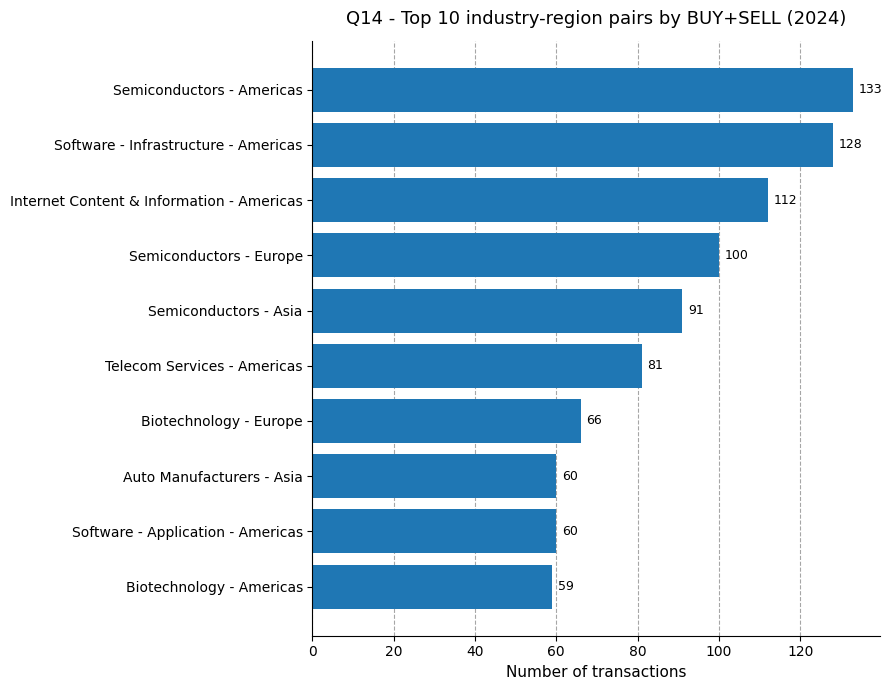

In [13]:

# Q14: TOP 10 INDUSTRY-REGION PAIRS BY TRANSACTIONS (BUY + SELL, 2024)

# Cross-dimensional analysis: roll-up along the Symbol hierarchy
# (Symbol -> Industry -> Sector) to Industry AND along the Geography
# hierarchy (Country -> SubRegion -> Region) to Region, counting fact rows.
# DIVIDENT rows are excluded because the question asks for BUY + SELL.

q14 = (buy_sell[buy_sell['Year'] == 2024]
       .groupby(['Industry', 'Region'])
       .size()
       .sort_values(ascending=False)
       .head(10))

# turn each (Industry, Region) tuple into a readable label
q14.index = [f'{industry} - {region}' for industry, region in q14.index]

print('Top 10 industry-region pairs by BUY+SELL in 2024:')
print(q14.to_string())
plot_ranking(q14, 'Q14 - Top 10 industry-region pairs by BUY+SELL (2024)', 'Number of transactions')



**Interpretation (Q14):** crossing the two hierarchies confirms, from yet another angle, the picture already seen in Q1, Q5 and Q7. The single most traded pair is **Semiconductors - Americas (133 transactions)**, followed by Software - Infrastructure - Americas (128) and Internet Content & Information - Americas (112): the top of the ranking is entirely American technology. The **Americas appear in 6 of the 10 pairs**, restating the geographic concentration found in Q5. **Semiconductors** is the only industry to surface in all three regions (Americas 133, Europe 100, Asia 91), which is the cross-dimensional counterpart of the chip-stock focus already visible at the ticker level in Q7 (ARM, AMD, TSM). In short, no matter how the cube is cut, portfolio activity gravitates towards American semiconductor and software names.